#Section 1
Problem and Population: The problem is the high cost of living in Silicon Valley, where low-income individuals struggle to afford basic necessities such as housing, food, and utilities. The person is Jane Campbell, a single mother working two part time jobs who is unable to consistently cover rent, childcare, and other expenses. The key failure point is not just insufficient income, but the lack of accessible, structured systems that help people identify and connect to relevant assistance programs. This relates to UN SDGs such as No Poverty and Reduced Inequalities. Compared to Milestone 1, the focus has shifted from general financial strain to specifically how AI can help interpret user needs and connect them to resources more effectively.

#Section 2
Proposed System:

Input:
A resident submits either a text message describing their financial situation or an image showing their living conditions.

AI Processing:

Lab 2 (Structured Data Extraction): The system extracts key information from text input, including location, primary need (housing, food, childcare, utilities), urgency level, recommended service, and resident language.
Lab 3 (Visual Recognition): The system analyzes images to identify visible environmental or housing issues, such as unsafe conditions, overcrowding, or signs of neglect.

Output:
A structured profile that summarizes the individual’s situation, including their main needs, urgency level, and suggested support services.

Real-World Action: The system delivers personalized recommendations directly to the user, helping them understand what support they qualify for and guiding them step by step on how to access those services.


#Section 3
Lab 2 & 3


In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


In [ ]:
resident_message = (
    "Jane Campbell, a single mother of two children living in Silicon Valley, who works two part time jobs to make ends meet. She struggles to "
    "pay monthly rent while also being able to afford food and electricity." #Here the user inputs a message describing their living conditions and poverty-related issues.
)

def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the location, identify the individual, and define the problem." #The AI will looks for the location, individual, and the problem from the user input message.
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    return response.text

print("--- Resident message ---")
print(resident_message)
print("\n--- Unstructured extraction (run 3 times — notice the format changes) ---")
print("\nRun 1:")
print(extract_unstructured(resident_message))
print("\nRun 2:")
print(extract_unstructured(resident_message))
print("\nRun 3:")
print(extract_unstructured(resident_message))

--- Resident message ---
Jane Campbell, a single mother of two children living in Silicon Valley, who works two part time jobs to make ends meet. She struggles to pay monthly rent while also being able to afford food and electricity.

--- Unstructured extraction (run 3 times — notice the format changes) ---

Run 1:
*   **Location:** Silicon Valley
*   **Individual:** Jane Campbell
*   **Problem:** Jane is experiencing financial hardship, struggling to afford basic necessities such as rent, food, and electricity, despite working two part-time jobs.

Run 2:
*   **Location:** Silicon Valley
*   **Individual:** Jane Campbell
*   **Problem:** Financial insecurity, struggling to afford basic necessities (rent, food, electricity) despite working two part-time jobs.

Run 3:
*   **Location:** Silicon Valley
*   **Individual:** Jane Campbell
*   **Problem:** She struggles to make ends meet, specifically affording monthly rent, food, and electricity, despite working two part-time jobs.


In [ ]:
# The schema — the form the AI must fill in exactly.
#The schema prompt specifies the five criteria that the AI system will look for and output when it analyzes the user input. This includes identifying the location, type of assistance needed,
#urgency of the situation, recommened department referral to seek support, and the inputted language.
schema_prompt = """
Extract information from this 311 resident complaint.
Return ONLY valid JSON with exactly these five fields:
{
  "location": string (the street address or location where the resident needs help),
  "need_type": string (the type of need or assistance described, e.g. "food insecurity", "unemployment", "housing assistance", "utility support"),
  "urgency": "LOW" or "MEDIUM" or "HIGH",
  "department": string (which San Jose city department should respond: e.g. "Social Services", "Food Assistance Program", "Housing Department", "Workforce Development"),
  "resident_language": string (language the resident wrote in, e.g. "English", "Spanish", "Vietnamese")
}
Urgency guide: LOW = information request or general support, MEDIUM = ongoing financial hardship or risk, HIGH = immediate or dire situation e.g. "no food or essentials", "homelessness", "eviction".
No explanation. No markdown. JSON only.
"""

print("Schema defined. The AI must return exactly these five fields:")
for field in ["location", "need_type", "urgency", "department", "resident_language"]:
    print(f"  - {field}")

Schema defined. The AI must return exactly these five fields:
  - location
  - need_type
  - urgency
  - department
  - resident_language


In [ ]:
def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    raw = response.text.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

print("--- Resident message ---")
print(resident_message)
print("\n--- Structured extraction (run 3 times — format is identical each time) ---")

for i in range(1, 4):
    print(f"\nRun {i}:")
    result = extract_structured(resident_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

--- Resident message ---
Jane Campbell, a single mother of two children living in Silicon Valley, who works two part time jobs to make ends meet. She struggles to pay monthly rent while also being able to afford food and electricity.

--- Structured extraction (run 3 times — format is identical each time) ---

Run 1:
{
  "location": "Silicon Valley",
  "need_type": "Housing assistance, food insecurity, utility support",
  "urgency": "MEDIUM",
  "department": "Social Services",
  "resident_language": "English"
}

Run 2:
{
  "location": "Silicon Valley",
  "need_type": "housing assistance, food insecurity, utility support",
  "urgency": "MEDIUM",
  "department": "Social Services",
  "resident_language": "English"
}

Run 3:
{
  "location": "Silicon Valley",
  "need_type": "housing assistance, food insecurity, utility support",
  "urgency": "MEDIUM",
  "department": "Social Services",
  "resident_language": "English"
}


In [ ]:
test_messages = [
    {
        "label": "Food Assistance",
        "message": "My food pantry at home is in short supply. "
                   "Is there any locations near Capitol Ave where I can receive food support?"
    },
    {
        "label": "Unemployment Help (Spanish)",
        "message": "Llevo tres meses desempleado. "
                   "¿Hay algún servicio de desempleo cerca de Capitol Avenue al que pueda acudir?"
    },
    {
        "label": "Homeless issue",
        "message": "I was evicted from my rental home on Capitol Ave after not being able to pay my rent. "
                   "I am worried as I have no place to stay and am homeless. "
                   "I'm worried that I won't be able to find a new home."
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()

=== Food Assistance ===
Input: My food pantry at home is in short supply. Is there any locations near Capitol Ave where I can receive food support?
Output:
{
  "location": "Capitol Ave",
  "need_type": "food insecurity",
  "urgency": "MEDIUM",
  "department": "Food Assistance Program",
  "resident_language": "English"
}

=== Unemployment Help (Spanish) ===
Input: Llevo tres meses desempleado. ¿Hay algún servicio de desempleo cerca de Capitol Avenue al que pueda acudir?
Output:
{
  "location": "Capitol Avenue",
  "need_type": "unemployment",
  "urgency": "MEDIUM",
  "department": "Workforce Development",
  "resident_language": "Spanish"
}

=== Homeless issue ===
Input: I was evicted from my rental home on Capitol Ave after not being able to pay my rent. I am worried as I have no place to stay and am homeless. I'm worried that I won't be able to find a new home.
Output:
{
  "location": "Capitol Ave",
  "need_type": "housing assistance",
  "urgency": "HIGH",
  "department": "Housing Depar

#Explanation of Lab 2:

This demonstrates the functionality of a structured data extraction AI system that can take user input of a description of their living conditions, and organize the information given into set criteria that helps illustrate the problem, as well as recommend support departments that help to solve the issue. This AI system works with different languages as well, so that users can use the AI system in their own language.

Saving labthing.jpg to labthing.jpg
Uploaded: labthing.jpg
Image size: 318x159 pixels


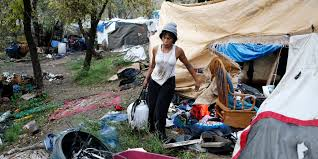

In [ ]:
# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


In [ ]:
civic_questions = [
    ("PROBLEM",  "Describe the economical problem visible in this image. Be specific about what you see."),
    ("IMPACT",   "What are the public health, safety, or community impacts of what is shown in this image?"),
    ("URGENCY",  "Rate the urgency of this situation as LOW - HIGH. Explain your reasoning in 2–3 sentences."),
    ("ACTION",   "Which specific department should respond to this? What action should they take?")
]

#The civic questions tell the AI system to identify and extract certain criteria from the image that it is analyzing, which include: the problem shown in the image (environmental, health, etc.),
#the impact of what is shown in the image (problem) which include public safety risks, health risks, etc, the urgency of the situation, and a recommendations of supportive departments that can
#help assist the problem shown in the image, as well as the specific actions the departments could take to solve the problem
civic_results = {"answers": {}, "total_tokens": 0}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
The primary economic problem vividly depicted in this image is **homelessness and extreme poverty**, stemming from a severe **lack of affordable housing and basic necessities**.

Here's what specifically in the image illustrates this:

1.  **Makeshift Shelters:** The entire visible landscape is dominated by numerous temporary structures: a white and red tent in the foreground, various tarpaulins strung up, and other improvised shelters made from different materials (like the tan tarp structure behind the woman). These indicate that the inhabitants cannot afford or access stable, permanent housing.
2.  **Lack of Sanitation and Infrastructure:** The ground is cluttered with an abundance of debris, discarded items, trash, and general disarray. This points to a severe lack of public services like waste management, sanitation (no visible plumbing or proper waste disposal), and basic infrastructure (no paved roads, electricity lines, or permanent buildings). This absence of s

In [ ]:
custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


Ask your own question about the image: Who can help these people?

--- Response ---
The people in the image appear to be experiencing homelessness and living in a makeshift encampment. Many different individuals and organizations can help people in this situation, providing a range of support from immediate relief to long-term solutions:

1.  **Government Agencies:**
    *   **Local Housing Authorities:** Can provide information on temporary shelters, emergency housing, and pathways to permanent housing.
    *   **Departments of Social Services:** Offer assistance with benefits, food stamps, healthcare, and connect individuals to various support programs.
    *   **Public Health Departments:** Can address sanitation issues, provide medical services, and manage outreach programs.
    *   **Veterans Affairs (VA):** For individuals who have served in the military, the VA offers specific programs for homeless veterans, including housing, healthcare, and mental health services.

2.  **Non-

#Explanation of Lab 3:
This demonstrates the functionality of an AI image-recognition system where the user inputs a photo of their or someone else' living conditions, and the AI will analyze the image and output the impact that the individual's living conditions depicted in the image have on themselves, their health, environment, and others. Additionally, the AI suggests support departments that can help the individual and describes the reasons why as well as how the support would help them. The AI also takes in questions from the user regarding the inputted image, and responds to their question in giving advice.

#Section 4

In [ ]:
edge_case_message = (
    "I’m doing okay for now, but sometimes I skip meals to save money. "
    "My kids eat fine though. Rent is high but I manage most months."
)

result = extract_structured(edge_case_message)
print(result)

{'location': '', 'need_type': 'food insecurity', 'urgency': 'MEDIUM', 'department': 'Food Assistance Program', 'resident_language': 'English'}


The system labeled this as MED urgency despite there being signs of food insecurity, the message includes major alerts like the skipping meals to save money and how they are barely making ends meet most months. This a failure because the AI underestimates the persons needs since it cannot detect major key words.